# Reference Card Extraction

This notebook now explores the reusable extraction code in `src/uno_vision/data/reference_cards.py`.
The heavy lifting lives in the package; the cells here focus on picking inputs, running the extractor, and visualizing the generated assets.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve()
while not (PROJECT_ROOT / "src").exists() and PROJECT_ROOT.parent != PROJECT_ROOT:
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / "src"))

import cv2
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

from uno_vision.data.reference_cards import _reference_binary_mask, extract_reference_card_assets
from uno_vision.paths import REFERENCE_CARDS_DIR, REFERENCE_IMAGES_DIR

print(f"Project root: {PROJECT_ROOT}")
print(f"Reference images: {REFERENCE_IMAGES_DIR}")
print(f"Processed outputs: {REFERENCE_CARDS_DIR}")

Project root: C:\Users\doria\Documents\EPFL\IA\iapr2026do\projodo
Reference images: C:\Users\doria\Documents\EPFL\IA\iapr2026do\projodo\data\raw\reference_images
Processed outputs: C:\Users\doria\Documents\EPFL\IA\iapr2026do\projodo\data\processed\reference_cards


In [2]:
image_name = "L1000768"
num_components = 16

image_path = REFERENCE_IMAGES_DIR / f"{image_name}.jpg"
gray = np.array(Image.open(image_path).convert("L"))
color_bgr = cv2.imread(str(image_path), cv2.IMREAD_COLOR)
color_rgb = cv2.cvtColor(color_bgr, cv2.COLOR_BGR2RGB)
adaptive, binary = _reference_binary_mask(gray)

print(f"Image: {image_path}")
print(f"Gray shape: {gray.shape}")

Image: C:\Users\doria\Documents\EPFL\IA\iapr2026do\projodo\data\raw\reference_images\L1000768.jpg
Gray shape: (2662, 4000)


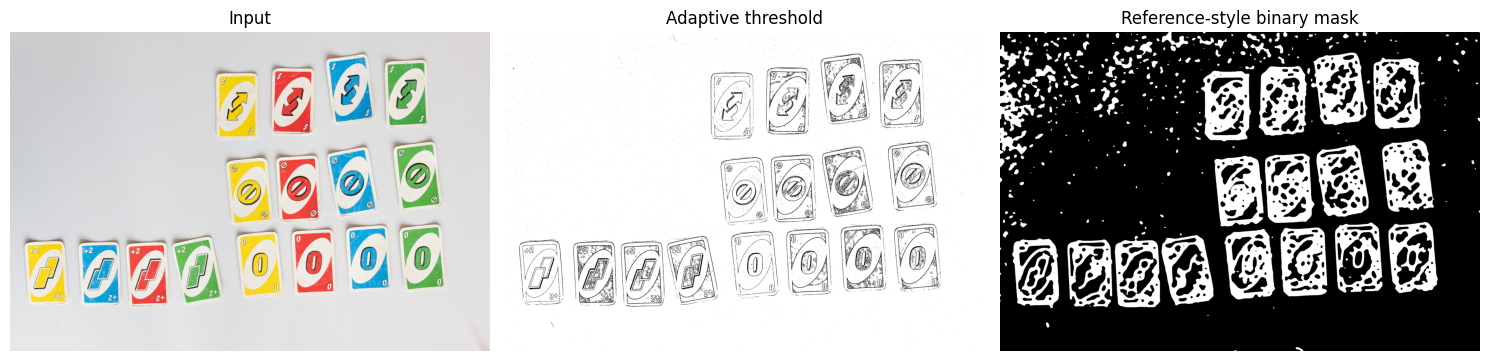

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(color_rgb)
axes[0].set_title("Input")
axes[0].axis("off")

axes[1].imshow(adaptive, cmap="gray")
axes[1].set_title("Adaptive threshold")
axes[1].axis("off")

axes[2].imshow(binary, cmap="gray")
axes[2].set_title("Reference-style binary mask")
axes[2].axis("off")

plt.tight_layout()
plt.show()

In [4]:
result = extract_reference_card_assets(image_name=image_name, num_components=num_components)

print(f"Output directory: {result.output_dir}")
print(f"Components: {len(result.components)}")
print(f"Masks:      {len(result.masks)}")
print(f"Crops:      {len(result.crops)}")

Output directory: C:\Users\doria\Documents\EPFL\IA\iapr2026do\projodo\data\processed\reference_cards\L1000768
Components: 16
Masks:      16
Crops:      16


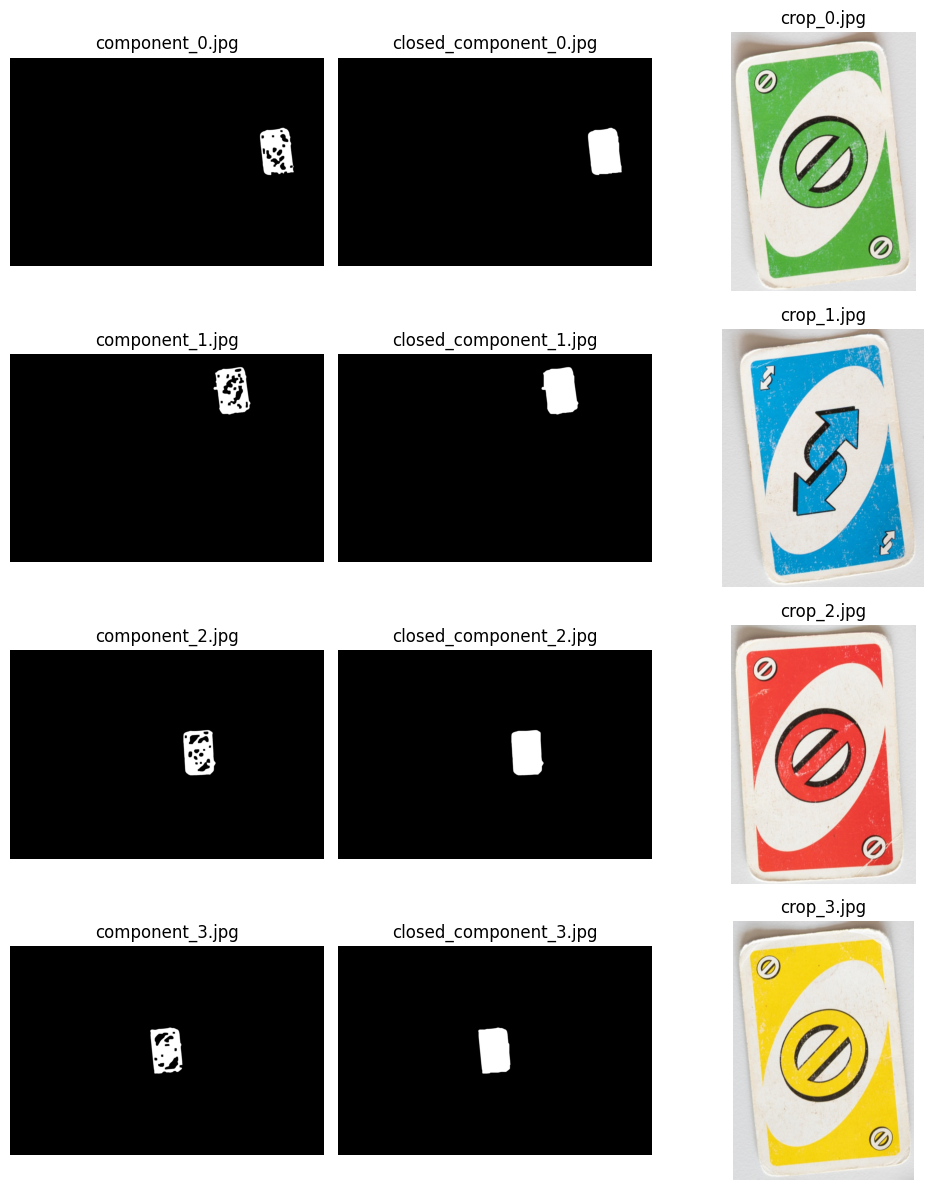

In [5]:
preview_rows = list(zip(result.components[:4], result.masks[:4], result.crops[:4]))
if not preview_rows:
    raise RuntimeError("No reference-card assets were generated.")

fig, axes = plt.subplots(len(preview_rows), 3, figsize=(10, 3 * len(preview_rows)))
axes = np.atleast_2d(axes)

for row_idx, (component_path, mask_path, crop_path) in enumerate(preview_rows):
    component = cv2.imread(str(component_path), cv2.IMREAD_GRAYSCALE)
    mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)
    crop = cv2.cvtColor(cv2.imread(str(crop_path), cv2.IMREAD_COLOR), cv2.COLOR_BGR2RGB)

    axes[row_idx, 0].imshow(component, cmap="gray")
    axes[row_idx, 0].set_title(component_path.name)
    axes[row_idx, 0].axis("off")

    axes[row_idx, 1].imshow(mask, cmap="gray")
    axes[row_idx, 1].set_title(mask_path.name)
    axes[row_idx, 1].axis("off")

    axes[row_idx, 2].imshow(crop)
    axes[row_idx, 2].set_title(crop_path.name)
    axes[row_idx, 2].axis("off")

plt.tight_layout()
plt.show()